In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
diabetes = datasets.load_diabetes()
type(diabetes)

sklearn.utils._bunch.Bunch

In [3]:
diabetes['data'].shape

(442, 10)

In [4]:
diabetes['target'].shape

(442,)

In [5]:
# train 382 instance test 80
X = diabetes['data']
y = diabetes['target']
X_train = X[:362]
y_train = y[:362]
X_test = X[362:]
y_test = y[362:]

In [6]:
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
lr.coef_ 
# 10 hệ số từ w1

array([   3.92718202, -253.94486874,  520.35846552,  300.42819747,
       -603.58774264,  325.27121483,   10.78855295,  139.51168049,
        669.05351038,  111.45789687])

In [8]:
lr.intercept_
# bias (giao điểm với trục tung)

np.float64(152.73013266423447)

In [9]:
lr_ridge = linear_model.Ridge()
lr_ridge.fit(X_train, y_train)
lr_ridge.coef_

array([  32.78954532,  -80.85926874,  271.69586887,  176.96641895,
         15.37272928,  -16.91575029, -139.96701751,  117.14604684,
        240.21724327,  123.42881129])

In [10]:
# bias
lr_ridge.intercept_

np.float64(152.46126379662914)

In [11]:
# instance đầu tiên của test
X_test[0], y_test[0]

(array([ 0.01991321,  0.05068012,  0.10480869,  0.0700723 , -0.03596778,
        -0.0266789 , -0.02499266, -0.00259226,  0.00370906,  0.04034337]),
 np.float64(321.0))

In [12]:
# dự đoán instance đầu tiên sử dụng hồi quy tuyến tính
print(f"true value: {y_test[0]}")
print(f"lr prediction: {lr.predict([X_test[0]])}") # chú ý đầu vào của predict phải là 1 mảng 2 chiều
print(f"lr_ridge prediction: {lr_ridge.predict([X_test[0]])}")

true value: 321.0
lr prediction: [234.90685728]
lr_ridge prediction: [198.85614321]


In [13]:
y_test.shape

(80,)

In [14]:
y_pred_lr = lr.predict(X_test)
df_stat = pd.DataFrame(data = np.array([y_test, y_pred_lr]).T, columns = ['Thực tế', 'Dự đoán'])
# chú ý phải lấy chuyển vị của ma trận data
df_stat['Lệch'] = np.abs(df_stat['Thực tế'] - df_stat['Dự đoán'])
df_stat 

,Thực tế,Dự đoán,Lệch
0,321.0,234.906857,86.093143
1,58.0,163.458562,105.458562
2,262.0,163.570686,98.429314
3,206.0,167.786320,38.213680
4,233.0,254.211062,21.211062
...,...,...,...
75,178.0,191.809194,13.809194
76,104.0,104.524821,0.524821
77,132.0,123.525247,8.474753
78,220.0,209.998994,10.001006


In [15]:
# tính rmse
np.sqrt(mean_squared_error(y_test, y_pred_lr))

np.float64(51.642237514353134)

In [16]:
# các giá trị hằng số phạt của ridge
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]
# tham số lambda trong ridge là alpha
for i in _lambda:
    ridge_model = linear_model.Ridge(alpha = i)
    ridge_model.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_test, ridge_model.predict(X_test)))
    print(f"lambda = {i}, rmse = {rmse}")

lambda = 0, rmse = 51.64223751435311
lambda = 0.0001, rmse = 51.649078311098904
lambda = 0.01, rmse = 51.97229255925035
lambda = 0.04, rmse = 52.179952000788646
lambda = 0.05, rmse = 52.217736616614076
lambda = 0.06, rmse = 52.25370884439912
lambda = 0.1, rmse = 52.403451674107785
lambda = 0.5, rmse = 54.63916408668823
lambda = 1, rmse = 57.40001081961914
lambda = 5, rmse = 67.25395495013551
lambda = 10, rmse = 71.19593942174217
lambda = 20, rmse = 74.06221030868194


In [17]:
y_test

array([321.,  58., 262., 206., 233., 242., 123., 167.,  63., 197.,  71.,
       168., 140., 217., 121., 235., 245.,  40.,  52., 104., 132.,  88.,
        69., 219.,  72., 201., 110.,  51., 277.,  63., 118.,  69., 273.,
       258.,  43., 198., 242., 232., 175.,  93., 168., 275., 293., 281.,
        72., 140., 189., 181., 209., 136., 261., 113., 131., 174., 257.,
        55.,  84.,  42., 146., 212., 233.,  91., 111., 152., 120.,  67.,
       310.,  94., 183.,  66., 173.,  72.,  49.,  64.,  48., 178., 104.,
       132., 220.,  57.])

C:\Users\HOANG QUOC CUONG\AppData\Local\Temp\ipykernel_19204\2887175508.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test)


<Axes: ylabel='Density'>

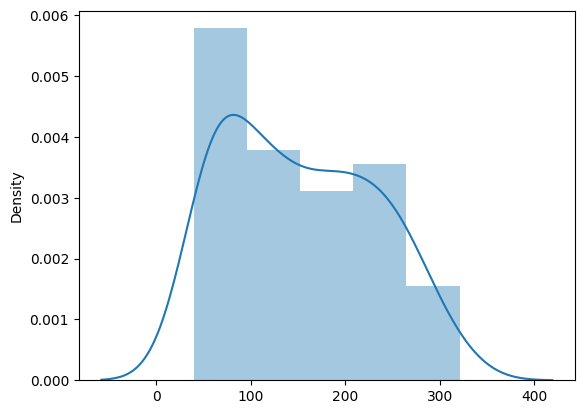

In [18]:
import seaborn as sns
sns.distplot(y_test)

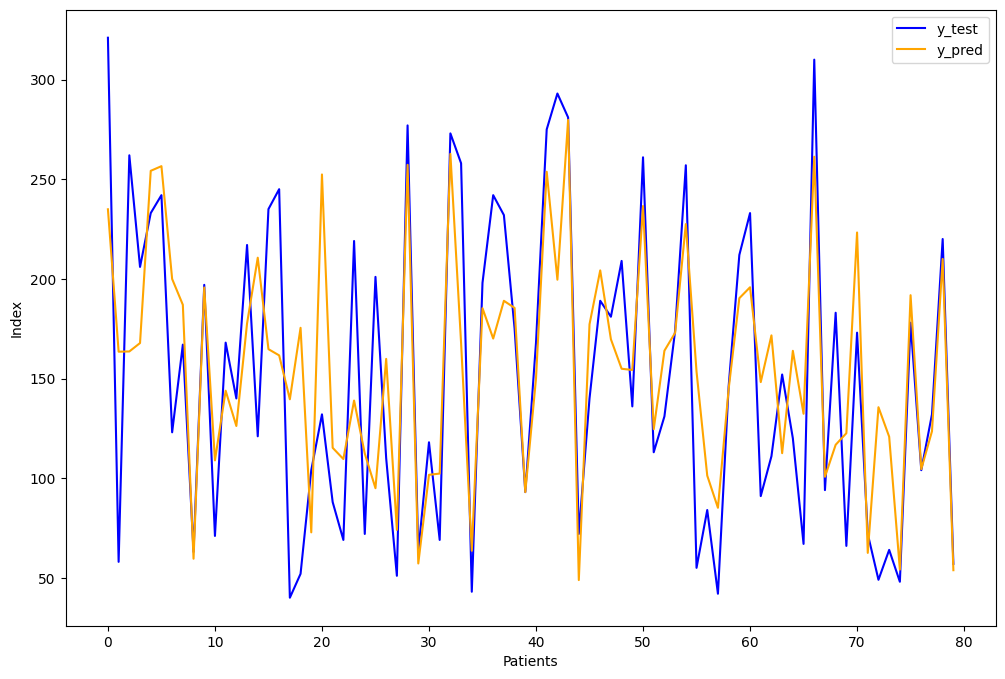

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(y_test, color = 'blue', label = 'y_test')
plt.plot(y_pred_lr, color = 'orange', label = 'y_pred')
plt.xlabel('Patients')
plt.ylabel('Index')
plt.legend()
